In [5]:
import os
import pandas as pd
import numpy as np
import json
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.stats.mstats import winsorize
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler,
    MaxAbsScaler, RobustScaler, Normalizer, PowerTransformer
)
from sklearn.compose import ColumnTransformer

current = os.path.abspath(os.getcwd())
candidates = [current, os.path.dirname(current)]
BASE_DIR = next(
    p for p in candidates
    if os.path.isdir(os.path.join(p, "Dataset"))
)

DATA_DIR = os.path.join(BASE_DIR, "Dataset")
FINAL_DIR = os.path.join(BASE_DIR, "Final Dataset")
os.makedirs(FINAL_DIR, exist_ok=True)

print("Libraries imported successfully!")
print("Dataset folder:", DATA_DIR)


Libraries imported successfully!
Dataset folder: c:\Users\indra\Downloads\Practicle DPP&FE\Dataset


# Step 2 — Data Import & Understanding

In [6]:
try:
    customers = pd.read_excel(os.path.join(DATA_DIR, "customers.xlsx"))
except ImportError:
    customers = pd.DataFrame({
        "customer_id": [101,102,103,104,105,106,107,108],
        "name": ["Aarav","Diya","Kabir","Meera","Vivaan","Anaya","Arjun","Ishita"],
        "age": [24,30,27,35,40,29,32,26],
        "gender": ["Male","Female","Male","Female","Male","Female","Male","Female"],
        "city": ["Mumbai","Delhi","Bangalore","Ahmedabad","Pune","Surat","Kolkata","Chennai"],
        "income": [45000,55000,48000,60000,75000,52000,68000,47000]
    })

print("Customers Dataset")
display(customers.head())
print("Shape:", customers.shape)
print("Columns:", customers.columns.tolist())


Customers Dataset


,customer_id,name,age,gender,city,income
0,101,Aarav,24,Male,Mumbai,45000
1,102,Diya,30,Female,Delhi,55000
2,103,Kabir,27,Male,Bangalore,48000
3,104,Meera,35,Female,Ahmedabad,60000
4,105,Vivaan,40,Male,Pune,75000


Shape: (8, 6)
Columns: ['customer_id', 'name', 'age', 'gender', 'city', 'income']


In [7]:
with open(os.path.join(DATA_DIR, "transactions.json"), "r", encoding="utf-8") as file:
    transactions_data = json.load(file)

transactions = pd.DataFrame(transactions_data)

print("Transactions Dataset")
display(transactions.head())
print("Shape:", transactions.shape)
print("Columns:", transactions.columns.tolist())


Transactions Dataset


,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07


Shape: (8, 6)
Columns: ['transaction_id', 'customer_id', 'product_id', 'amount', 'payment_mode', 'date']


In [8]:
conn = sqlite3.connect(":memory:")

with open(os.path.join(DATA_DIR, "products.sql"), "r", encoding="utf-8") as file:
    sql_script = file.read()

conn.executescript(sql_script)

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)

print("Available Tables:")
display(tables)


Available Tables:


,name
0,products


In [9]:
products = pd.read_sql_query("SELECT * FROM products", conn)

print("Products Dataset")
display(products.head())

print("\nShape:", products.shape)

print("\nColumns:")
print(products.columns.tolist())

Products Dataset


,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,50
1,P002,Bluetooth Speaker,Audio,699,40
2,P003,Smart Watch,Wearable,1299,25
3,P004,Keyboard,Computer,899,60
4,P005,Headphones,Audio,1999,30



Shape: (6, 5)

Columns:
['product_id', 'product_name', 'category', 'price', 'stock']


In [10]:
api_url = "https://dummyjson.com/users"

try:
    response = requests.get(api_url, timeout=10)
    response.raise_for_status()
    print("Status Code:", response.status_code)
except requests.RequestException as e:
    response = None
    print("API request skipped:", e)


Status Code: 200


In [11]:
if response is not None:
    api_data = response.json()
    api_users = pd.DataFrame(api_data["users"])
else:
    api_users = pd.DataFrame(columns=["id"])

print("API Users Dataset")
print("Shape:", api_users.shape)
display(api_users.head())
print("API Columns:", api_users.columns.tolist())


API Users Dataset
Shape: (30, 28)


,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


API Columns: ['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress', 'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto', 'role']


In [12]:
print("API Users Dataset")
print("Shape:", api_users.shape)

display(api_users.head())

API Users Dataset
Shape: (30, 28)


,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


In [13]:
if "id" in api_users.columns:
    print("API ID range:")
    print(api_users["id"].tolist())


API ID range:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [14]:
print("API ID range:")
print(api_users["id"].tolist())

API ID range:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


### API integration check

In [15]:
customer_ids = set(customers["customer_id"])
api_ids = set(api_users["id"]) if "id" in api_users.columns else set()
matching_ids = customer_ids.intersection(api_ids)

print("Matching customer/API IDs:", matching_ids)
print("Number of matching IDs:", len(matching_ids))

if len(matching_ids) == 0:
    print("No valid common key was found; API data was not merged.")


Matching customer/API IDs: set()
Number of matching IDs: 0
No valid common key was found; API data was not merged.


In [16]:
print("CUSTOMERS")
print(customers.shape)
print(customers.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.shape)
print(transactions.columns.tolist())

print("\nPRODUCTS")
print(products.shape)
print(products.columns.tolist())

CUSTOMERS
(8, 6)
['customer_id', 'name', 'age', 'gender', 'city', 'income']

TRANSACTIONS
(8, 6)
['transaction_id', 'customer_id', 'product_id', 'amount', 'payment_mode', 'date']

PRODUCTS
(6, 5)
['product_id', 'product_name', 'category', 'price', 'stock']


In [17]:
display(customers.head())
display(transactions.head())
display(products.head())

,customer_id,name,age,gender,city,income
0,101,Aarav,24,Male,Mumbai,45000
1,102,Diya,30,Female,Delhi,55000
2,103,Kabir,27,Male,Bangalore,48000
3,104,Meera,35,Female,Ahmedabad,60000
4,105,Vivaan,40,Male,Pune,75000


,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07


,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,50
1,P002,Bluetooth Speaker,Audio,699,40
2,P003,Smart Watch,Wearable,1299,25
3,P004,Keyboard,Computer,899,60
4,P005,Headphones,Audio,1999,30


In [18]:
customer_transactions = pd.merge(
    customers,
    transactions,
    on="customer_id",
    how="left"
)

print("Customer + Transaction Dataset")
print("Shape:", customer_transactions.shape)

display(customer_transactions.head())

Customer + Transaction Dataset
Shape: (8, 11)


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05


In [19]:
combined_data = pd.merge(
    customer_transactions,
    products,
    on="product_id",
    how="left"
)

print("Final Combined Dataset")
print("Shape:", combined_data.shape)

display(combined_data.head())

Final Combined Dataset
Shape: (8, 15)


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


In [20]:
print("HEAD")
display(combined_data.head())

print("INFO")
combined_data.info()

print("DESCRIPTIVE STATISTICS")
display(combined_data.describe(include="all"))

HEAD


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     8 non-null      int64 
 1   name            8 non-null      object
 2   age             8 non-null      int64 
 3   gender          8 non-null      object
 4   city            8 non-null      object
 5   income          8 non-null      int64 
 6   transaction_id  8 non-null      object
 7   product_id      8 non-null      object
 8   amount          8 non-null      int64 
 9   payment_mode    8 non-null      object
 10  date            8 non-null      object
 11  product_name    8 non-null      object
 12  category        8 non-null      object
 13  price           8 non-null      int64 
 14  stock           8 non-null      int64 
dtypes: int64(6), object(9)
memory usage: 1.1+ KB
DESCRIPTIVE STATISTICS


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
count,8.00000,8,8.000000,8,8,8.000000,8,8,8.000000,8,8,8,8,8.000000,8.000000
unique,NaN,8,NaN,2,8,NaN,8,6,NaN,4,8,6,5,NaN,NaN
top,NaN,Aarav,NaN,Male,Mumbai,NaN,T001,P001,NaN,UPI,2025-10-01,Earphones,Electronics,NaN,NaN
freq,NaN,1,NaN,4,1,NaN,1,2,NaN,3,1,2,2,NaN,NaN
mean,104.50000,NaN,30.000000,NaN,NaN,54125.000000,NaN,NaN,1249.000000,NaN,NaN,NaN,NaN,1224.000000,37.500000
std,2.44949,NaN,5.903994,NaN,NaN,10494.045931,NaN,NaN,755.928946,NaN,NaN,NaN,NaN,749.761867,14.638501
min,101.00000,NaN,22.000000,NaN,NaN,42000.000000,NaN,NaN,499.000000,NaN,NaN,NaN,NaN,499.000000,20.000000
25%,102.75000,NaN,26.250000,NaN,NaN,47250.000000,NaN,NaN,649.000000,NaN,NaN,NaN,NaN,649.000000,25.000000
50%,104.50000,NaN,29.500000,NaN,NaN,52500.000000,NaN,NaN,1099.000000,NaN,NaN,NaN,NaN,1099.000000,35.000000
75%,106.25000,NaN,33.500000,NaN,NaN,58500.000000,NaN,NaN,1624.000000,NaN,NaN,NaN,NaN,1474.000000,50.000000


In [21]:
print("Duplicate rows:", combined_data.duplicated().sum())


Duplicate rows: 0


# Step 3 — Exploratory Data Analysis (EDA)

In [22]:
numerical_cols = combined_data.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_cols.tolist())

Numerical Columns:
['customer_id', 'age', 'income', 'amount', 'price', 'stock']


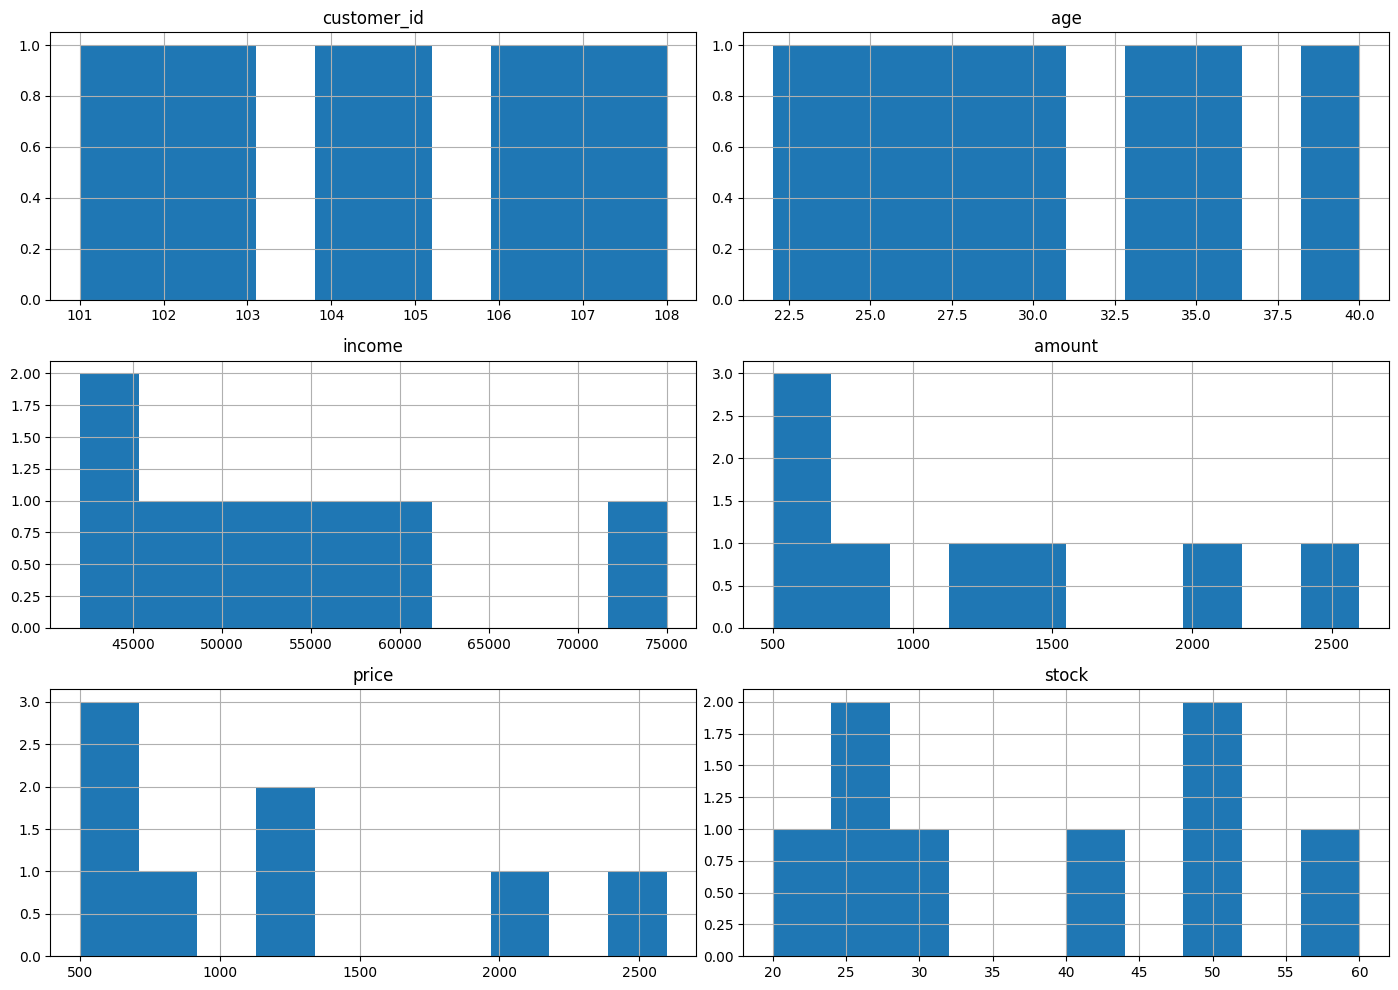

In [23]:
combined_data[numerical_cols].hist(
    figsize=(14, 10),
    bins=10
)

plt.tight_layout()
plt.show()

In [24]:
categorical_cols = combined_data.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['name', 'gender', 'city', 'transaction_id', 'product_id', 'payment_mode', 'date', 'product_name', 'category']


In [25]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(combined_data[col].value_counts())


--- name ---
name
Aarav     1
Diya      1
Kabir     1
Meera     1
Vivaan    1
Riya      1
Aryan     1
Isha      1
Name: count, dtype: int64

--- gender ---
gender
Male      4
Female    4
Name: count, dtype: int64

--- city ---
city
Mumbai       1
Delhi        1
Bangalore    1
Ahmedabad    1
Pune         1
Chennai      1
Kolkata      1
Surat        1
Name: count, dtype: int64

--- transaction_id ---
transaction_id
T001    1
T007    1
T002    1
T003    1
T004    1
T008    1
T005    1
T006    1
Name: count, dtype: int64

--- product_id ---
product_id
P001    2
P003    2
P002    1
P005    1
P004    1
P006    1
Name: count, dtype: int64

--- payment_mode ---
payment_mode
UPI            3
Credit Card    2
Cash           2
Debit Card     1
Name: count, dtype: int64

--- date ---
date
2025-10-01    1
2025-10-09    1
2025-10-02    1
2025-10-03    1
2025-10-05    1
2025-10-10    1
2025-10-07    1
2025-10-08    1
Name: count, dtype: int64

--- product_name ---
product_name
Earphones            2

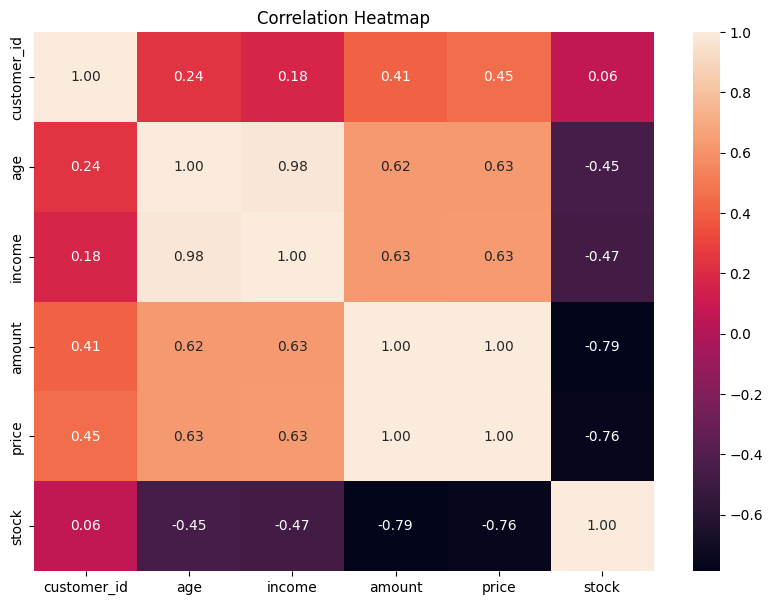

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    combined_data[numerical_cols].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

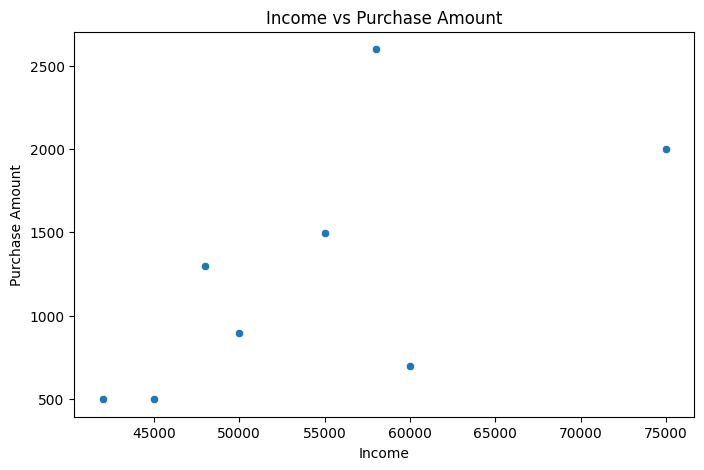

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=combined_data,
    x="income",
    y="amount"
)

plt.title("Income vs Purchase Amount")
plt.xlabel("Income")
plt.ylabel("Purchase Amount")

plt.show()

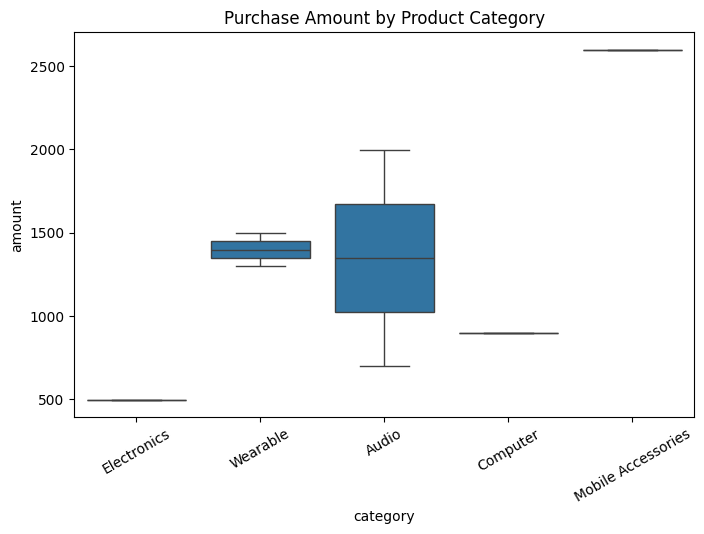

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_data,
    x="category",
    y="amount"
)

plt.title("Purchase Amount by Product Category")
plt.xticks(rotation=30)

plt.show()

# Step 4 — Missing Data Analysis & Imputation

In [29]:
missing_values = combined_data.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
customer_id       0
name              0
age               0
gender            0
city              0
income            0
transaction_id    0
product_id        0
amount            0
payment_mode      0
date              0
product_name      0
category          0
price             0
stock             0
dtype: int64


In [30]:
missing_percentage = (combined_data.isnull().sum() / len(combined_data)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
customer_id       0.0
name              0.0
age               0.0
gender            0.0
city              0.0
income            0.0
transaction_id    0.0
product_id        0.0
amount            0.0
payment_mode      0.0
date              0.0
product_name      0.0
category          0.0
price             0.0
stock             0.0
dtype: float64


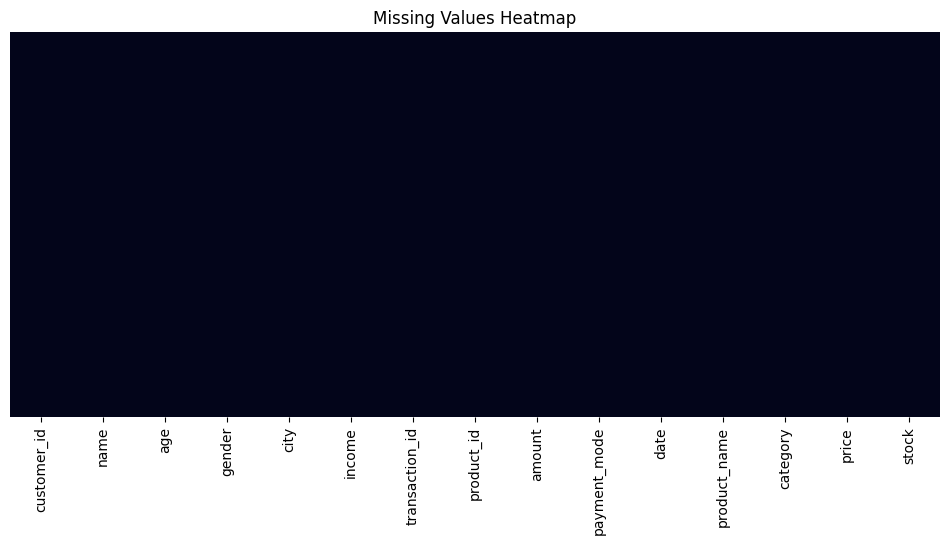

In [31]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    combined_data.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

In [32]:
missing_summary = pd.DataFrame({
    "Missing_Count": combined_data.isnull().sum(),
    "Missing_Percentage": combined_data.isnull().mean() * 100
})

display(missing_summary)

,Missing_Count,Missing_Percentage
customer_id,0,0.0
name,0,0.0
age,0,0.0
gender,0,0.0
city,0,0.0
income,0,0.0
transaction_id,0,0.0
product_id,0,0.0
amount,0,0.0
payment_mode,0,0.0


In [33]:
imputation_data = combined_data.copy()

In [34]:
imputation_data.loc[1, "age"] = np.nan
imputation_data.loc[3, "income"] = np.nan
imputation_data.loc[5, "city"] = np.nan
imputation_data.loc[7, "gender"] = np.nan

In [35]:
print("Missing values introduced for demonstration:")
display(imputation_data.isnull().sum())

Missing values introduced for demonstration:


customer_id       0
name              0
age               1
gender            1
city              1
income            1
transaction_id    0
product_id        0
amount            0
payment_mode      0
date              0
product_name      0
category          0
price             0
stock             0
dtype: int64

In [36]:
imputation_data["age"] = imputation_data["age"].fillna(
    imputation_data["age"].median()
)

imputation_data["income"] = imputation_data["income"].fillna(
    imputation_data["income"].median()
)

In [37]:
imputation_data["city"] = imputation_data["city"].fillna(
    imputation_data["city"].mode()[0]
)

imputation_data["gender"] = imputation_data["gender"].fillna(
    imputation_data["gender"].mode()[0]
)

In [38]:
print("Remaining missing values:")
print(imputation_data[["age", "income", "city", "gender"]].isnull().sum())

Remaining missing values:
age       0
income    0
city      0
gender    0
dtype: int64


In [39]:
knn_data = combined_data[["age", "income", "amount", "price", "stock"]].copy()

knn_data.loc[1, "age"] = np.nan
knn_data.loc[3, "income"] = np.nan

print("Before KNN Imputation:")
display(knn_data)

Before KNN Imputation:


,age,income,amount,price,stock
0,24.0,45000.0,499,499,50
1,NaN,55000.0,1499,1299,25
2,27.0,48000.0,1299,1299,25
3,35.0,NaN,699,699,40
4,40.0,75000.0,1999,1999,30
5,22.0,42000.0,499,499,50
6,29.0,50000.0,899,899,60
7,33.0,58000.0,2599,2599,20


In [40]:
knn_imputer = KNNImputer(n_neighbors=3)

knn_result = pd.DataFrame(
    knn_imputer.fit_transform(knn_data),
    columns=knn_data.columns
)

print("After KNN Imputation:")
display(knn_result)

After KNN Imputation:


,age,income,amount,price,stock
0,24.000000,45000.000000,499.0,499.0,50.0
1,32.333333,55000.000000,1499.0,1299.0,25.0
2,27.000000,48000.000000,1299.0,1299.0,25.0
3,35.000000,45666.666667,699.0,699.0,40.0
4,40.000000,75000.000000,1999.0,1999.0,30.0
5,22.000000,42000.000000,499.0,499.0,50.0
6,29.000000,50000.000000,899.0,899.0,60.0
7,33.000000,58000.000000,2599.0,2599.0,20.0


In [41]:
print("Missing values after KNN:")
print(knn_result.isnull().sum())

Missing values after KNN:
age       0
income    0
amount    0
price     0
stock     0
dtype: int64


In [42]:
mice_data = combined_data[["age", "income", "amount", "price", "stock"]].copy()

mice_data.loc[2, "age"] = np.nan
mice_data.loc[4, "income"] = np.nan

print("Before MICE:")
display(mice_data)

Before MICE:


,age,income,amount,price,stock
0,24.0,45000.0,499,499,50
1,30.0,55000.0,1499,1299,25
2,NaN,48000.0,1299,1299,25
3,35.0,60000.0,699,699,40
4,40.0,NaN,1999,1999,30
5,22.0,42000.0,499,499,50
6,29.0,50000.0,899,899,60
7,33.0,58000.0,2599,2599,20


In [44]:
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

mice_result = pd.DataFrame(
    mice_imputer.fit_transform(mice_data),
    columns=mice_data.columns
)

print("After MICE:")
display(mice_result)
print("Missing values after MICE:")
print(mice_result.isnull().sum())

After MICE:


,age,income,amount,price,stock
0,24.000000,45000.000000,499.0,499.0,50.0
1,30.000000,55000.000000,1499.0,1299.0,25.0
2,27.822882,48000.000000,1299.0,1299.0,25.0
3,35.000000,60000.000000,699.0,699.0,40.0
4,40.000000,53899.157339,1999.0,1999.0,30.0
5,22.000000,42000.000000,499.0,499.0,50.0
6,29.000000,50000.000000,899.0,899.0,60.0
7,33.000000,58000.000000,2599.0,2599.0,20.0


Missing values after MICE:
age       0
income    0
amount    0
price     0
stock     0
dtype: int64


In [45]:
complete_case_data = combined_data.dropna().copy()
print("Complete Case Analysis rows:", complete_case_data.shape[0])
print("Rows removed:", combined_data.shape[0] - complete_case_data.shape[0])


Complete Case Analysis rows: 8
Rows removed: 0


### Imputation Methods Comparison


# Step 5 — Outlier Detection

In [46]:
outlier_data = combined_data[
    ["age", "income", "amount", "price", "stock"]
].copy()

z_scores = np.abs(zscore(outlier_data))

z_outliers = (z_scores > 3).any(axis=1)

print("Number of Z-score outlier rows:", z_outliers.sum())

display(outlier_data[z_outliers])

Number of Z-score outlier rows: 0


,age,income,amount,price,stock


In [47]:
Q1 = outlier_data.quantile(0.25)
Q3 = outlier_data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = (
    (outlier_data < lower_bound) |
    (outlier_data > upper_bound)
).any(axis=1)

print("Number of IQR outlier rows:", iqr_outliers.sum())

display(outlier_data[iqr_outliers])

Number of IQR outlier rows: 0


,age,income,amount,price,stock


In [48]:
lower_percentile = outlier_data.quantile(0.01)
upper_percentile = outlier_data.quantile(0.99)

percentile_outliers = (
    (outlier_data < lower_percentile) |
    (outlier_data > upper_percentile)
).any(axis=1)

print(
    "Number of percentile-based outlier rows:",
    percentile_outliers.sum()
)

display(outlier_data[percentile_outliers])

Number of percentile-based outlier rows: 4


,age,income,amount,price,stock
4,40,75000,1999,1999,30
5,22,42000,499,499,50
6,29,50000,899,899,60
7,33,58000,2599,2599,20


In [49]:
from scipy.stats.mstats import winsorize

winsorized_data = outlier_data.copy()

for col in winsorized_data.columns:
    winsorized_data[col] = winsorize(
        winsorized_data[col],
        limits=[0.05, 0.05]
    )

print("Winsorized Data:")
display(winsorized_data)

Winsorized Data:


,age,income,amount,price,stock
0,24,45000,499,499,50
1,30,55000,1499,1299,25
2,27,48000,1299,1299,25
3,35,60000,699,699,40
4,40,75000,1999,1999,30
5,22,42000,499,499,50
6,29,50000,899,899,60
7,33,58000,2599,2599,20


# Step 6 — Date/Time & Mixed Variables

In [50]:
combined_data["date"] = pd.to_datetime(combined_data["date"])

print("Date datatype:")
print(combined_data["date"].dtype)

display(combined_data[["customer_id", "date"]].head())

Date datatype:
datetime64[ns]


,customer_id,date
0,101,2025-10-01
1,102,2025-10-09
2,103,2025-10-02
3,104,2025-10-03
4,105,2025-10-05


In [51]:
reference_date = combined_data["date"].max()

combined_data["days_since_last_purchase"] = (
    reference_date - combined_data["date"]
).dt.days

print("Reference Date:", reference_date)

display(
    combined_data[
        ["customer_id", "date", "days_since_last_purchase"]
    ]
)



Reference Date: 2025-10-10 00:00:00


,customer_id,date,days_since_last_purchase
0,101,2025-10-01,9
1,102,2025-10-09,1
2,103,2025-10-02,8
3,104,2025-10-03,7
4,105,2025-10-05,5
5,106,2025-10-10,0
6,107,2025-10-07,3
7,108,2025-10-08,2


### Date-derived features

In [52]:
# Extract useful calendar features from the transaction date
combined_data["purchase_year"] = combined_data["date"].dt.year
combined_data["purchase_month"] = combined_data["date"].dt.month
combined_data["purchase_dayofweek"] = combined_data["date"].dt.dayofweek

display(
    combined_data[
        ["date", "purchase_year", "purchase_month", "purchase_dayofweek"]
    ].head()
)


,date,purchase_year,purchase_month,purchase_dayofweek
0,2025-10-01,2025,10,2
1,2025-10-09,2025,10,3
2,2025-10-02,2025,10,3
3,2025-10-03,2025,10,4
4,2025-10-05,2025,10,6


### Mixed Variable Handling

The customer_id column was inspected for mixed alphanumeric values. In the supplied dataset, customer_id contains numeric identifiers only, so no mixed-format ID conversion was required.

In [53]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               8 non-null      int64         
 1   name                      8 non-null      object        
 2   age                       8 non-null      int64         
 3   gender                    8 non-null      object        
 4   city                      8 non-null      object        
 5   income                    8 non-null      int64         
 6   transaction_id            8 non-null      object        
 7   product_id                8 non-null      object        
 8   amount                    8 non-null      int64         
 9   payment_mode              8 non-null      object        
 10  date                      8 non-null      datetime64[ns]
 11  product_name              8 non-null      object        
 12  category                  

# Step 7 — Categorical Encoding

In [54]:
from sklearn.preprocessing import LabelEncoder

encoding_data = combined_data.copy()

label_encoder = LabelEncoder()

encoding_data["gender_encoded"] = label_encoder.fit_transform(
    encoding_data["gender"]
)

display(
    encoding_data[
        ["gender", "gender_encoded"]
    ]
)

,gender,gender_encoded
0,Male,1
1,Female,0
2,Male,1
3,Female,0
4,Male,1
5,Female,0
6,Male,1
7,Female,0


In [55]:
print("Label Encoding Mapping:")

for label, code in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(label, "->", code)

Label Encoding Mapping:
Female -> 0
Male -> 1


In [56]:
onehot_data = pd.get_dummies(
    combined_data,
    columns=["city", "payment_mode"],
    prefix=["city", "payment"]
)

display(onehot_data.head())

,customer_id,name,age,gender,income,transaction_id,product_id,amount,date,product_name,...,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_Cash,payment_Credit Card,payment_Debit Card,payment_UPI
0,101,Aarav,24,Male,45000,T001,P001,499,2025-10-01,Earphones,...,False,False,False,True,False,False,False,False,False,True
1,102,Diya,30,Female,55000,T007,P003,1499,2025-10-09,Smart Watch,...,False,True,False,False,False,False,False,True,False,False
2,103,Kabir,27,Male,48000,T002,P003,1299,2025-10-02,Smart Watch,...,False,False,False,False,False,False,False,True,False,False
3,104,Meera,35,Female,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,False,True,False
4,105,Vivaan,40,Male,75000,T004,P005,1999,2025-10-05,Headphones,...,False,False,False,False,True,False,False,False,False,True


In [57]:
print("One-Hot Encoded Columns:")

print([
    col for col in onehot_data.columns
    if col.startswith("city_") or col.startswith("payment_")
])

One-Hot Encoded Columns:
['city_Ahmedabad', 'city_Bangalore', 'city_Chennai', 'city_Delhi', 'city_Kolkata', 'city_Mumbai', 'city_Pune', 'city_Surat', 'payment_Cash', 'payment_Credit Card', 'payment_Debit Card', 'payment_UPI']


In [58]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_demo = pd.DataFrame({
    "satisfaction": [
        "Low",
        "Medium",
        "High",
        "Medium",
        "High"
    ]
})

ordinal_encoder = OrdinalEncoder(
    categories=[["Low", "Medium", "High"]]
)

ordinal_demo["satisfaction_encoded"] = ordinal_encoder.fit_transform(
    ordinal_demo[["satisfaction"]]
)

display(ordinal_demo)

,satisfaction,satisfaction_encoded
0,Low,0.0
1,Medium,1.0
2,High,2.0
3,Medium,1.0
4,High,2.0


In [59]:
income_bins = [0, 50000, 70000, np.inf]

income_labels = [
    "Low",
    "Medium",
    "High"
]

encoding_data["income_group"] = pd.cut(
    encoding_data["income"],
    bins=income_bins,
    labels=income_labels
)

display(
    encoding_data[
        ["income", "income_group"]
    ]
)
    

,income,income_group
0,45000,Low
1,55000,Medium
2,48000,Low
3,60000,Medium
4,75000,High
5,42000,Low
6,50000,Low
7,58000,Medium


In [60]:
income_ordinal_encoder = OrdinalEncoder(
    categories=[["Low", "Medium", "High"]]
)

encoding_data["income_group_encoded"] = (
    income_ordinal_encoder.fit_transform(
        encoding_data[["income_group"]]
    )
)

display(
    encoding_data[
        ["income", "income_group", "income_group_encoded"]
    ]
    
)

,income,income_group,income_group_encoded
0,45000,Low,0.0
1,55000,Medium,1.0
2,48000,Low,0.0
3,60000,Medium,1.0
4,75000,High,2.0
5,42000,Low,0.0
6,50000,Low,0.0
7,58000,Medium,1.0


# Step 8 — Feature Scaling

In [61]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    Normalizer
)

scaling_data = combined_data[
    ["age", "income", "amount", "price", "stock"]
].copy()

display(scaling_data.head())

,age,income,amount,price,stock
0,24,45000,499,499,50
1,30,55000,1499,1299,25
2,27,48000,1299,1299,25
3,35,60000,699,699,40
4,40,75000,1999,1999,30


In [62]:
standard_scaler = StandardScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(scaling_data),
    columns=scaling_data.columns
)

print("StandardScaler:")
display(standard_scaled.head())

StandardScaler:


,age,income,amount,price,stock
0,-1.086429,-0.929578,-1.060660,-1.033738,0.912871
1,0.000000,0.089138,0.353553,0.106938,-0.912871
2,-0.543214,-0.623963,0.070711,0.106938,-0.912871
3,0.905357,0.598495,-0.777817,-0.748569,0.182574
4,1.810715,2.126569,1.060660,1.105031,-0.547723


In [63]:
minmax_scaler = MinMaxScaler()

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(scaling_data),
    columns=scaling_data.columns
)

print("MinMaxScaler:")
display(minmax_scaled.head())

MinMaxScaler:


,age,income,amount,price,stock
0,0.111111,0.090909,0.000000,0.000000,0.750
1,0.444444,0.393939,0.476190,0.380952,0.125
2,0.277778,0.181818,0.380952,0.380952,0.125
3,0.722222,0.545455,0.095238,0.095238,0.500
4,1.000000,1.000000,0.714286,0.714286,0.250


In [64]:
maxabs_scaler = MaxAbsScaler()

maxabs_scaled = pd.DataFrame(
    maxabs_scaler.fit_transform(scaling_data),
    columns=scaling_data.columns
)

print("MaxAbsScaler:")
display(maxabs_scaled.head())

MaxAbsScaler:


,age,income,amount,price,stock
0,0.600,0.600000,0.191997,0.191997,0.833333
1,0.750,0.733333,0.576760,0.499808,0.416667
2,0.675,0.640000,0.499808,0.499808,0.416667
3,0.875,0.800000,0.268950,0.268950,0.666667
4,1.000,1.000000,0.769142,0.769142,0.500000


In [65]:
robust_scaler = RobustScaler()

robust_scaled = pd.DataFrame(
    robust_scaler.fit_transform(scaling_data),
    columns=scaling_data.columns
)

print("RobustScaler:")
display(robust_scaled.head())

RobustScaler:


,age,income,amount,price,stock
0,-0.758621,-0.666667,-0.615385,-0.727273,0.6
1,0.068966,0.222222,0.410256,0.242424,-0.4
2,-0.344828,-0.400000,0.205128,0.242424,-0.4
3,0.758621,0.666667,-0.410256,-0.484848,0.2
4,1.448276,2.000000,0.923077,1.090909,-0.2


In [66]:
normalizer = Normalizer()

normalized_data = pd.DataFrame(
    normalizer.fit_transform(scaling_data),
    columns=scaling_data.columns
)

print("Normalizer:")
display(normalized_data.head())

Normalizer:


,age,income,amount,price,stock
0,0.000533,0.999876,0.011088,0.011088,0.001111
1,0.000545,0.999350,0.027237,0.023603,0.000454
2,0.000562,0.999268,0.027043,0.027043,0.000520
3,0.000583,0.999864,0.011648,0.011648,0.000667
4,0.000533,0.999290,0.026634,0.026634,0.000400


In [67]:
print("Original Data:")
display(scaling_data.head())

print("StandardScaler:")
display(standard_scaled.head())

print("MinMaxScaler:")
display(minmax_scaled.head())

print("MaxAbsScaler:")
display(maxabs_scaled.head())

print("RobustScaler:")
display(robust_scaled.head())

print("Normalizer:")
display(normalized_data.head())

Original Data:


,age,income,amount,price,stock
0,24,45000,499,499,50
1,30,55000,1499,1299,25
2,27,48000,1299,1299,25
3,35,60000,699,699,40
4,40,75000,1999,1999,30


StandardScaler:


,age,income,amount,price,stock
0,-1.086429,-0.929578,-1.060660,-1.033738,0.912871
1,0.000000,0.089138,0.353553,0.106938,-0.912871
2,-0.543214,-0.623963,0.070711,0.106938,-0.912871
3,0.905357,0.598495,-0.777817,-0.748569,0.182574
4,1.810715,2.126569,1.060660,1.105031,-0.547723


MinMaxScaler:


...

,age,income,amount,price,stock
0,0.600,0.600000,0.191997,0.191997,0.833333
1,0.750,0.733333,0.576760,0.499808,0.416667
2,0.675,0.640000,0.499808,0.499808,0.416667
3,0.875,0.800000,0.268950,0.268950,0.666667
4,1.000,1.000000,0.769142,0.769142,0.500000


RobustScaler:


,age,income,amount,price,stock
0,-0.758621,-0.666667,-0.615385,-0.727273,0.6
1,0.068966,0.222222,0.410256,0.242424,-0.4
2,-0.344828,-0.400000,0.205128,0.242424,-0.4
3,0.758621,0.666667,-0.410256,-0.484848,0.2
4,1.448276,2.000000,0.923077,1.090909,-0.2


Normalizer:


,age,income,amount,price,stock
0,0.000533,0.999876,0.011088,0.011088,0.001111
1,0.000545,0.999350,0.027237,0.023603,0.000454
2,0.000562,0.999268,0.027043,0.027043,0.000520
3,0.000583,0.999864,0.011648,0.011648,0.000667
4,0.000533,0.999290,0.026634,0.026634,0.000400


In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "standard",
            StandardScaler(),
            ["age", "income"]
        ),
        (
            "minmax",
            MinMaxScaler(),
            ["amount", "price", "stock"]
        )
    ]
)

column_transformer_result = preprocessor.fit_transform(
    combined_data
)

print("ColumnTransformer output shape:")
print(column_transformer_result.shape)

ColumnTransformer output shape:
(8, 5)


# Step 9 — Feature Construction & Transformation

In [69]:
feature_data = combined_data.copy()

feature_data["total_purchases"] = (
    feature_data.groupby("customer_id")["transaction_id"]
    .transform("count")
)

display(
    feature_data[
        ["customer_id", "transaction_id", "total_purchases"]
    ]
)

,customer_id,transaction_id,total_purchases
0,101,T001,1
1,102,T007,1
2,103,T002,1
3,104,T003,1
4,105,T004,1
5,106,T008,1
6,107,T005,1
7,108,T006,1


In [70]:
feature_data["amount_per_purchase"] = (
    feature_data["amount"] /
    feature_data["total_purchases"]
)

display(
    feature_data[
        ["amount", "total_purchases", "amount_per_purchase"]
    ].head()
)

,amount,total_purchases,amount_per_purchase
0,499,1,499.0
1,1499,1,1499.0
2,1299,1,1299.0
3,699,1,699.0
4,1999,1,1999.0


In [71]:
feature_data["log_amount"] = np.log1p(
    feature_data["amount"]
)

display(
    feature_data[
        ["amount", "log_amount"]
    ].head()
)

,amount,log_amount
0,499,6.214608
1,1499,7.313220
2,1299,7.170120
3,699,6.551080
4,1999,7.600902


In [72]:
feature_data["sqrt_amount"] = np.sqrt(
    feature_data["amount"]
)

display(
    feature_data[
        ["amount", "sqrt_amount"]
    ].head()
)

,amount,sqrt_amount
0,499,22.338308
1,1499,38.716921
2,1299,36.041643
3,699,26.438608
4,1999,44.710178


In [73]:
feature_data["reciprocal_amount"] = (
    1 / feature_data["amount"]
)

display(
    feature_data[
        ["amount", "reciprocal_amount"]
    ].head()
)

,amount,reciprocal_amount
0,499,0.002004
1,1499,0.000667
2,1299,0.000770
3,699,0.001431
4,1999,0.000500


In [74]:
boxcox_transformer = PowerTransformer(
    method="box-cox"
)

feature_data["amount_box_cox"] = (
    boxcox_transformer.fit_transform(
        feature_data[["amount"]]
    ).ravel()
)

display(
    feature_data[
        ["amount", "amount_box_cox"]
    ].head()
)

,amount,amount_box_cox
0,499,-1.311750
1,1499,0.612825
2,1299,0.371644
3,699,-0.704128
4,1999,1.089428


In [75]:
power_transformer = PowerTransformer(method="yeo-johnson")

feature_data["amount_yeo_johnson"] = (
    power_transformer.fit_transform(
        feature_data[["amount"]]
    ).ravel()
)

print("Yeo-Johnson transformation completed.")
display(
    feature_data[
        ["amount", "amount_yeo_johnson"]
    ].head()
)

Yeo-Johnson transformation completed.


,amount,amount_yeo_johnson
0,499,-1.311663
1,1499,0.612803
2,1299,0.371587
3,699,-0.704225
4,1999,1.089470


In [76]:
income_bins = [0, 50000, 70000, np.inf]

income_labels = ["Low", "Medium", "High"]

feature_data["income_group"] = pd.cut(
    feature_data["income"],
    bins=income_bins,
    labels=income_labels
)

display(
    feature_data[["income", "income_group"]]
)

,income,income_group
0,45000,Low
1,55000,Medium
2,48000,Low
3,60000,Medium
4,75000,High
5,42000,Low
6,50000,Low
7,58000,Medium


In [77]:
purchase_threshold = 1

feature_data["frequent_buyer"] = (
    feature_data["total_purchases"] > purchase_threshold
).astype(int)

display(
    feature_data[
        ["customer_id", "total_purchases", "frequent_buyer"]
    ]
)

,customer_id,total_purchases,frequent_buyer
0,101,1,0
1,102,1,0
2,103,1,0
3,104,1,0
4,105,1,0
5,106,1,0
6,107,1,0
7,108,1,0


In [78]:
new_features = [
    "total_purchases",
    "amount_per_purchase",
    "log_amount",
    "sqrt_amount",
    "reciprocal_amount",
    "amount_yeo_johnson",
    "amount_box_cox",
    "income_group",
    "frequent_buyer"
]

display(feature_data[new_features].head())

,total_purchases,amount_per_purchase,log_amount,sqrt_amount,reciprocal_amount,amount_yeo_johnson,amount_box_cox,income_group,frequent_buyer
0,1,499.0,6.214608,22.338308,0.002004,-1.311663,-1.311750,Low,0
1,1,1499.0,7.313220,38.716921,0.000667,0.612803,0.612825,Medium,0
2,1,1299.0,7.170120,36.041643,0.000770,0.371587,0.371644,Low,0
3,1,699.0,6.551080,26.438608,0.001431,-0.704225,-0.704128,Medium,0
4,1,1999.0,7.600902,44.710178,0.000500,1.089470,1.089428,High,0


# Step 10 — Final Processed Dataset

In [79]:
# Start from the engineered dataset
final_data = feature_data.copy()

# Encode categorical variables that are useful for the final feature matrix.
final_data["gender_encoded"] = LabelEncoder().fit_transform(final_data["gender"])

# Preserve the intended order of income groups.
income_encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
final_data["income_group_encoded"] = income_encoder.fit_transform(
    final_data[["income_group"]]
).ravel()

# One-hot encode nominal categorical variables.
final_data = pd.get_dummies(
    final_data,
    columns=["city", "payment_mode", "category", "product_name"],
    prefix=["city", "payment", "category", "product"],
    dtype=int
)

# Scale continuous numerical features for the final feature matrix.
continuous_features = [
    "age",
    "income",
    "amount",
    "price",
    "stock",
    "days_since_last_purchase",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "total_purchases",
    "amount_per_purchase",
    "log_amount",
    "sqrt_amount",
    "reciprocal_amount",
    "amount_yeo_johnson",
    "amount_box_cox",
]

scaler = StandardScaler()
final_data[continuous_features] = scaler.fit_transform(
    final_data[continuous_features]
)

# Remove identifiers/raw text fields that are not useful as model features.
drop_columns = [
    "name",
    "transaction_id",
    "product_id",
    "date",
    "gender",
    "income_group",
]

final_data = final_data.drop(columns=drop_columns)

# Keep customer_id as an identifier.
final_data = final_data.sort_values("customer_id").reset_index(drop=True)

print("Final processed dataset shape:", final_data.shape)
display(final_data.head())


Final processed dataset shape: (8, 43)


,customer_id,age,income,amount,price,stock,days_since_last_purchase,purchase_year,purchase_month,purchase_dayofweek,...,category_Computer,category_Electronics,category_Mobile Accessories,category_Wearable,product_Bluetooth Speaker,product_Earphones,product_Headphones,product_Keyboard,product_Power Bank,product_Smart Watch
0,101,-1.086429,-0.929578,-1.060660,-1.033738,0.912871,1.463697,0.0,0.0,-0.774597,...,0,1,0,0,0,1,0,0,0,0
1,102,0.000000,0.089138,0.353553,0.106938,-0.912871,-1.068103,0.0,0.0,-0.086066,...,0,0,0,1,0,0,0,0,0,1
2,103,-0.543214,-0.623963,0.070711,0.106938,-0.912871,1.147222,0.0,0.0,-0.086066,...,0,0,0,1,0,0,0,0,0,1
3,104,0.905357,0.598495,-0.777817,-0.748569,0.182574,0.830747,0.0,0.0,0.602464,...,0,0,0,0,1,0,0,0,0,0
4,105,1.810715,2.126569,1.060660,1.105031,-0.547723,0.197797,0.0,0.0,1.979525,...,0,0,0,0,0,0,1,0,0,0


In [80]:
output_path = os.path.join(FINAL_DIR, "processed_customer_data.csv")
final_data.to_csv(output_path, index=False)

print("Processed dataset saved successfully.")
print("File:", output_path)
print("Rows and columns:", final_data.shape)
print("Total missing values:", int(final_data.isnull().sum().sum()))


Processed dataset saved successfully.
File: c:\Users\indra\Downloads\Practicle DPP&FE\Final Dataset\processed_customer_data.csv
Rows and columns: (8, 43)
Total missing values: 0


### Final Validation

The checks below confirm that the exported dataset has no missing values and that the expected engineered features were incorporated.


In [81]:
print("Final columns:")
print(final_data.columns.tolist())

print("\nMissing values:")
print(final_data.isnull().sum())

print("\nFinal dataset information:")
final_data.info()


Final columns:
['customer_id', 'age', 'income', 'amount', 'price', 'stock', 'days_since_last_purchase', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'total_purchases', 'amount_per_purchase', 'log_amount', 'sqrt_amount', 'reciprocal_amount', 'amount_box_cox', 'amount_yeo_johnson', 'frequent_buyer', 'gender_encoded', 'income_group_encoded', 'city_Ahmedabad', 'city_Bangalore', 'city_Chennai', 'city_Delhi', 'city_Kolkata', 'city_Mumbai', 'city_Pune', 'city_Surat', 'payment_Cash', 'payment_Credit Card', 'payment_Debit Card', 'payment_UPI', 'category_Audio', 'category_Computer', 'category_Electronics', 'category_Mobile Accessories', 'category_Wearable', 'product_Bluetooth Speaker', 'product_Earphones', 'product_Headphones', 'product_Keyboard', 'product_Power Bank', 'product_Smart Watch']

Missing values:
customer_id                    0
age                            0
income                         0
amount                         0
price                          0
stock        